# Breast Cancer Prediction — BLR vs Classification Decision Tree

**Objective:** Predict whether a breast cancer case is malignant or benign.
Two models are built and compared:
- Binary Logistic Regression (BLR)
- Classification Decision Tree (pruned)

**Dataset:** breast_cancer_data.csv
**Key question:** Which model performs better for this medical classification problem?

## Part 1 — Binary Logistic Regression (BLR)

In [1]:
# Import all necessary libraries
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn import metrics
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree

import warnings
warnings.filterwarnings('ignore')

In [2]:
# Firstly import and load data
df = pd.read_csv('breast_cancer_data.csv', index_col='id')

# Drop NaN column
df.drop('Unnamed: 32', axis=1, inplace=True)

# Sense check
print(df.info())
df.head()

<class 'pandas.core.frame.DataFrame'>
Index: 569 entries, 842302 to 92751
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   diagnosis                569 non-null    object 
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  fractal_dimension_mean   569 non-null    float64
 11  radius_se                569 non-null    float64
 12  texture_se               569 non-null    float64
 13  perimeter_se             569 non-null    float64
 14  area_se                 

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
id,,,,,,,,,,,,,,,,,,,,,
842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [3]:
# I will now check for null values
print(df.isnull().sum())

diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64


In [4]:
# And here print the descriptive statistics
df.describe()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


In [5]:
# I will now check class balance of target variable
df['diagnosis'].value_counts()


diagnosis
B    357
M    212
Name: count, dtype: int64

In [6]:
# B (benign) = 357, M (malignant) = 212
# Slightly unbalanced but acceptable — no SMOTE needed

## BLR Step 1 — Prepare Data
I will convert diagnosis to binary (M=1, B=0) for logistic regression.
BLR requires a numeric binary dependent variable.

In [8]:
# Convert diagnosis to binary — M=1 (cancer), B=0 (healthy)
df_blr = df.copy()
df_blr['diagnosis'] = df_blr['diagnosis'].map({'M': 1, 'B': 0})

# Define X and y
X = df_blr.drop('diagnosis', axis=1)
y = df_blr['diagnosis']

# Train/test split — 70/30
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=0
)

## BLR Step 2 — At this point I will Fit and Evaluate

In [10]:
# Fit BLR model
logreg = LogisticRegression(max_iter=10000)
logreg.fit(X_train, y_train)

# Predict on test set
y_pred_blr = logreg.predict(X_test)

# Accuracy
blr_accuracy = accuracy_score(y_test, y_pred_blr)
print('BLR Accuracy:', round(blr_accuracy * 100, 2), '%')


BLR Accuracy: 95.91 %


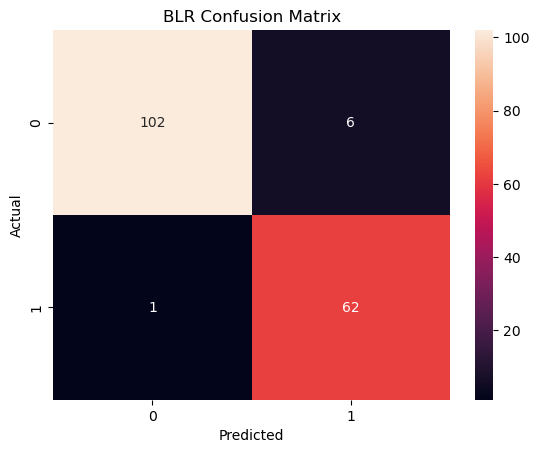

              precision    recall  f1-score   support

           0       0.99      0.94      0.97       108
           1       0.91      0.98      0.95        63

    accuracy                           0.96       171
   macro avg       0.95      0.96      0.96       171
weighted avg       0.96      0.96      0.96       171



In [11]:
# I will now create a Confusion matrix
cm_blr = confusion_matrix(y_test, y_pred_blr)

sns.heatmap(cm_blr, annot=True, fmt='g')
plt.title('BLR Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Classification report
print(classification_report(y_test, y_pred_blr))

## Part 2 — Classification Decision Tree
Decision trees handle string categories directly — no need to encode diagnosis.
I will reload the original data with B/M labels intact.

In [12]:
# The first step is to reload the data with original string labels for decision tree
df2 = df.copy()

# Define X and y
y2 = df2['diagnosis']
X2 = df2.drop('diagnosis', axis=1)

# I use the same split parameters for fair comparison
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2,
    test_size=0.3,
    random_state=0
)

## Decision Tree Step 1 — Fit Unpruned Tree
The unpruned tree will likely overfit — near 100% training accuracy 
but lower test accuracy. This demonstrates why pruning is necessary which I will execute after.

In [13]:
# Unpruned decision tree
clf = DecisionTreeClassifier(random_state=0)
clf.fit(X2_train, y2_train)
print('Unpruned training accuracy:', round(clf.score(X2_train, y2_train) * 100, 2), '%')
print('Unpruned test accuracy:', round(clf.score(X2_test, y2_test) * 100, 2), '%')

Unpruned training accuracy: 100.0 %
Unpruned test accuracy: 91.23 %


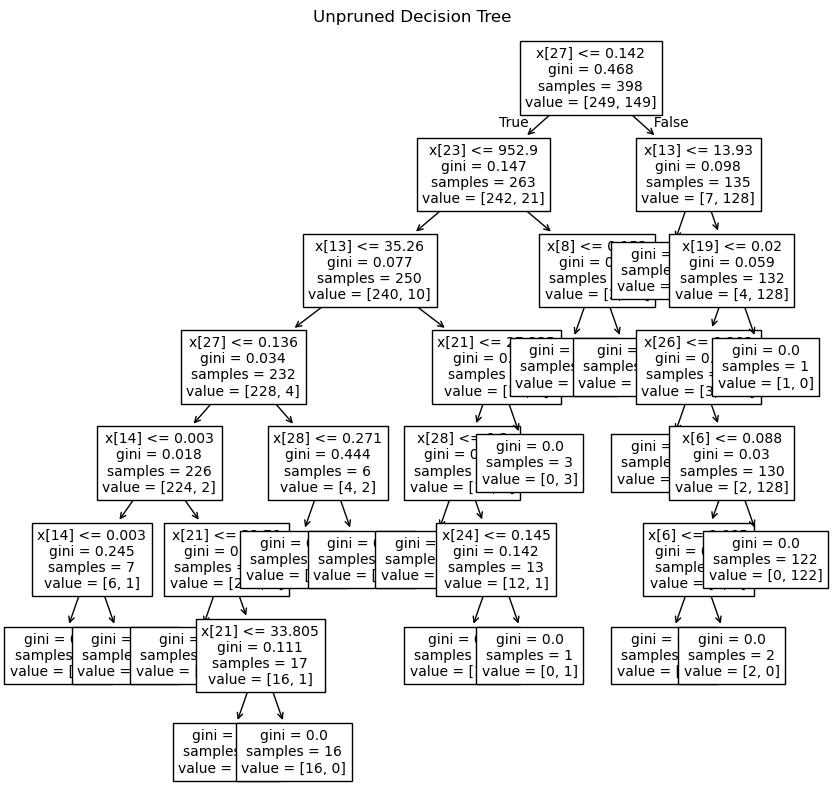

In [14]:
# I now visualise the unpruned tree
fig, ax = plt.subplots(figsize=(10, 10))
tree.plot_tree(clf, fontsize=10)
plt.title('Unpruned Decision Tree')
plt.show()
# Will be very large and complex, evidence of overfitting as mentioned earlier

## Decision Tree Step 2 — Prune the Tree
At this point I will apply pruning parameters to control growth and reduce overfitting:
- criterion='gini' — splits chosen to minimise Gini impurity
- max_depth=5 — tree can only grow 5 levels deep
- min_samples_leaf=5 — each leaf must have at least 5 samples
- min_samples_split=5 — a node needs at least 5 samples to split

In [15]:
# Below is the code for a pruned decision tree
clf_pruned = DecisionTreeClassifier(
    criterion='gini',
    max_depth=5,
    min_samples_leaf=5,
    min_samples_split=5,
    random_state=0)
clf_pruned.fit(X2_train, y2_train)
y_pred_dt = clf_pruned.predict(X2_test)
dt_accuracy = accuracy_score(y2_test, y_pred_dt)
print('Pruned training accuracy:', round(clf_pruned.score(X2_train, y2_train) * 100, 2), '%')
print('Pruned test accuracy:', round(dt_accuracy * 100, 2), '%')

Pruned training accuracy: 96.23 %
Pruned test accuracy: 95.91 %


In [16]:
#95.91% — pruning fixed the overfitting

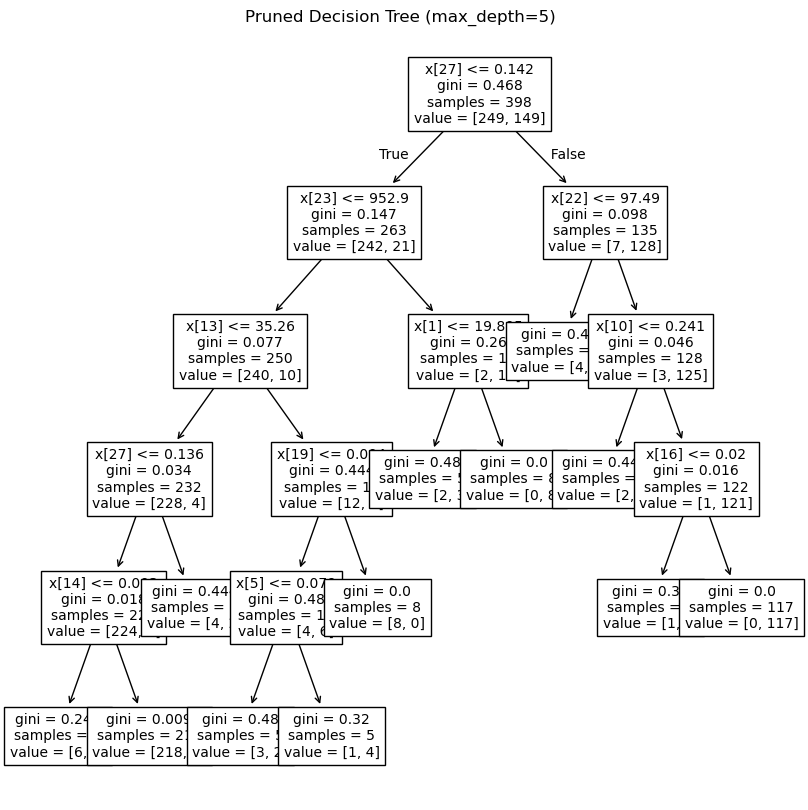

In [17]:
# Following the succesful pruning I now visualise the pruned tree
fig, ax = plt.subplots(figsize=(10, 10))
tree.plot_tree(clf_pruned, fontsize=10)
plt.title('Pruned Decision Tree (max_depth=5)')
plt.show()
# I am expecting something far simpler than above

            predicted_healthy  predicted_cancer
is_healthy                104                 4
is_cancer                   3                60


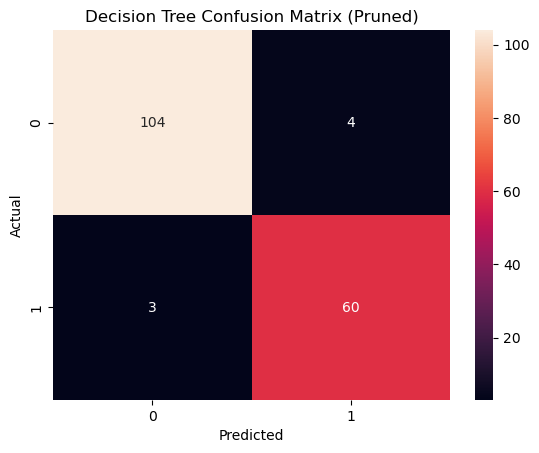

              precision    recall  f1-score   support

           B       0.97      0.96      0.97       108
           M       0.94      0.95      0.94        63

    accuracy                           0.96       171
   macro avg       0.95      0.96      0.96       171
weighted avg       0.96      0.96      0.96       171



In [18]:
# Decision tree confusion matrix is needed again
cm_dt = confusion_matrix(y2_test, y_pred_dt)
confusion = pd.DataFrame(
    cm_dt,
    index=['is_healthy', 'is_cancer'],
    columns=['predicted_healthy', 'predicted_cancer'])
print(confusion)
sns.heatmap(cm_dt, annot=True, fmt='g')
plt.title('Decision Tree Confusion Matrix (Pruned)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()
print(classification_report(y2_test, y_pred_dt))

## Part 3 — Final Model on All Available Data
I now train the final pruned model on the complete dataset for deployment.

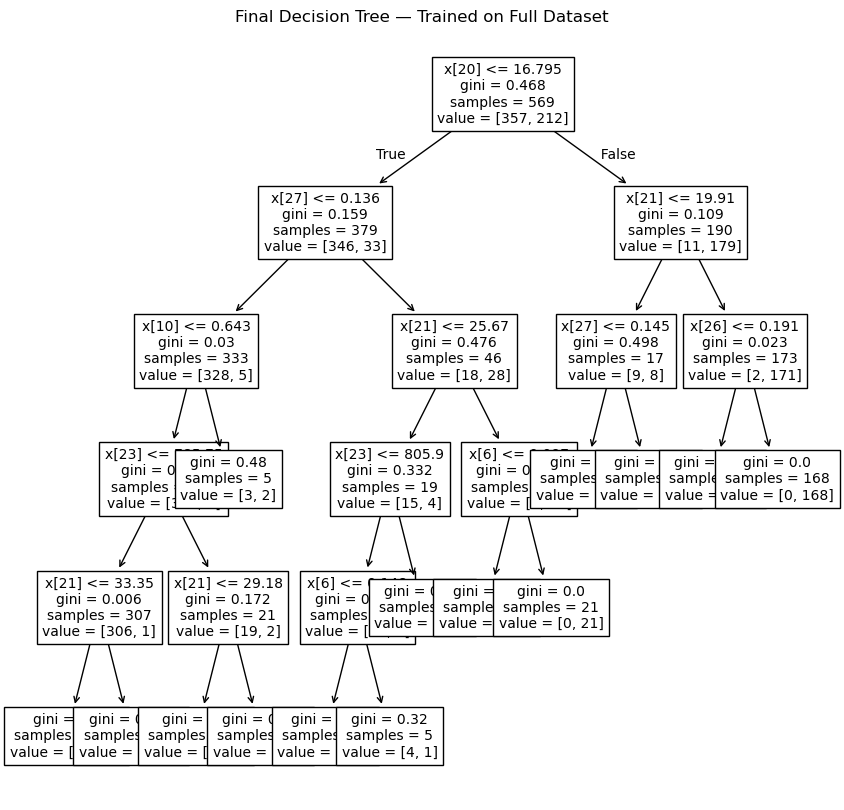

In [19]:
# Final model trained on all data
clff = DecisionTreeClassifier(
    criterion='gini',
    max_depth=5,
    min_samples_leaf=5,
    min_samples_split=5,
    random_state=0
)

clff.fit(X2, y2)

# Visualise final tree
fig, ax = plt.subplots(figsize=(10, 10))
tree.plot_tree(clff, fontsize=10)
plt.title('Final Decision Tree — Trained on Full Dataset')
plt.show()

## Part 4 — Model Comparison and Conclusion

## Summary and Observations

**Results:**

| Model | Training Accuracy | Test Accuracy |
|---|---|---|
| Binary Logistic Regression | — | 95.91% |
| Decision Tree (unpruned) | 100.0% | 91.23% |
| Decision Tree (pruned) | — | 95.91% |

**Key observations:**

1. **Overfitting is real** — the unpruned tree achieved 100% training accuracy 
   but only 91.23% on unseen data. It memorised the training data rather than 
   learning the underlying pattern. Pruning corrected this.

2. **Pruning works** — applying max_depth=5, min_samples_leaf=5, and 
   min_samples_split=5 brought test accuracy from 91.23% up to 95.91%, 
   matching BLR exactly.

3. **Both models achieve 95.91% accuracy** — neither is clearly superior 
   on this dataset in terms of overall accuracy.

4. **In a medical context, recall matters most** — a false negative 
   (predicting healthy when actually cancer) is far more dangerous than 
   a false positive. Check the classification report for recall scores 
   per class to determine which model is safer for clinical use.

5. **Interpretability advantage** — the decision tree plot shows exactly 
   which features drive each split, making it easier to explain to clinicians. 
   BLR provides probability scores which may be useful for borderline cases.

6. **These results outperform the Telcom churn model (79%)** — reflecting 
   that the breast cancer dataset has cleaner, more predictive features.

**Conclusion:**
Both models perform equally well at 95.91% accuracy. The decision tree 
is preferred where clinical explainability is required. BLR is preferred 
where probability scores add value. In practice, both would be presented 
to stakeholders and the final choice made based on the specific clinical 
and operational context.